# PCMCI: Causal Discovery in Time Series

**PCMCI** (Peter-Clark with Momentary Conditional Independence) is a causal discovery algorithm designed for detecting causal links in **multivariate time series** data. It was introduced by Runge et al. (2019) and is particularly well-suited for high-dimensional, autocorrelated data.

---

## Table of Contents
1. [Background & Motivation](#background)
2. [Key Concepts](#concepts)
3. [The PCMCI Algorithm](#algorithm)
4. [Worked Example with Synthetic Data](#example)
5. [Interpreting the Output](#output)
6. [Strengths & Limitations](#limits)
7. [References](#refs)

---
## 1. Background & Motivation <a name="background"></a>

Standard correlation analysis tells us **if** two variables are related, but not **why** or **in which direction**. In time series settings (climate, finance, neuroscience, etc.) we often want to answer:

> *Does variable X at time t−τ **cause** variable Y at time t?*

Classical approaches like Granger causality work but struggle with:
- **High dimensionality** — many variables → spurious links from indirect paths
- **Autocorrelation** — variables predicting themselves inflate significance
- **Indirect links** — A→B→C may falsely look like A→C

PCMCI addresses all three.

---
## 2. Key Concepts <a name="concepts"></a>

### 2.1 Causal Graph (Time Series DAG)

PCMCI represents causal relationships as a **time-lagged causal graph** — a Directed Acyclic Graph (DAG) where:
- Nodes are variable-time pairs: $X_t^j$ = variable $j$ at time $t$
- Edges represent causal influences: $X_{t-\tau}^i \to X_t^j$ means variable $i$ at lag $\tau$ causes variable $j$ at time $t$

```
  X(t-2)──►X(t-1)──►X(t)
     │                ▲
     └───────────────►│
  Y(t-2)──►Y(t-1)──►Y(t)
```

### 2.2 Conditional Independence (CI)

The core operation in PCMCI is testing **conditional independence**:

$$X \perp\!\!\!\perp Y \mid \mathbf{Z}$$

Read: *X is independent of Y given the conditioning set Z.* If this holds, there is no direct causal link between X and Y (once we account for Z).

### 2.3 Momentary Conditional Independence (MCI)

The key innovation of PCMCI. Instead of a generic CI test, it uses:

$$X_{t-\tau}^i \perp\!\!\!\perp X_t^j \mid \mathcal{P}(X_t^j), \mathcal{P}(X_{t-\tau}^i)$$

Where $\mathcal{P}$ denotes the **parents** (causal predecessors) of a variable in the graph. This conditions on **both** the target's parents and the source's parents, which:
- Controls for autocorrelation of the source
- Removes indirect links that pass through common parents
- Dramatically reduces false positives

---
## 3. The PCMCI Algorithm <a name="algorithm"></a>

PCMCI runs in **two phases**:

### Phase 1 — PC (Peter-Clark) Algorithm: Parent Identification

Goal: find a compact set of **parents** $\hat{\mathcal{P}}(X_t^j)$ for each variable $j$.

1. Start with all lagged variables up to max lag $\tau_{max}$ as potential parents
2. Iteratively remove variables that are conditionally independent of $X_t^j$ given a growing conditioning set
3. Repeat until no more variables can be removed

This is essentially **feature selection** via CI testing — it prunes irrelevant lags.

### Phase 2 — MCI Tests: Causal Link Detection

For every candidate link $(X_{t-\tau}^i \to X_t^j)$, test:

$$\text{MCI}(i, j, \tau): \quad X_{t-\tau}^i \perp\!\!\!\perp X_t^j \mid \hat{\mathcal{P}}(X_t^j) \setminus \{X_{t-\tau}^i\},\ \hat{\mathcal{P}}(X_{t-\tau}^i)$$

If the test **rejects** independence → a causal link is declared.

### Flowchart

```
Input: Multivariate time series {X^1, X^2, ..., X^N}
       Max lag τ_max, significance level α
         │
         ▼
┌─────────────────────────────┐
│   Phase 1: PC Algorithm     │
│  (for each variable j)      │
│  - Start with all lags      │
│  - CI test + iterative prune│
│  - Output: parents P̂(X^j)   │
└────────────┬────────────────┘
             │
             ▼
┌─────────────────────────────┐
│   Phase 2: MCI Tests        │
│  (for all i, j, τ pairs)    │
│  - MCI conditional test     │
│  - Multiple testing correct.│
│  - Output: causal graph     │
└─────────────────────────────┘
```

### CI Test Options

| Test | Best for |
|------|----------|
| `ParCorr` | Linear, Gaussian data |
| `GPDC` | Nonlinear, continuous data |
| `CMIknn` | Nonlinear, any distribution |
| `RobustParCorr` | Linear with outliers |

---
## 4. Worked Example with Synthetic Data <a name="example"></a>

We'll generate a simple 3-variable time series with **known** causal structure, then use PCMCI to recover it.

**True causal structure:**
- $X_0(t-1) \to X_0(t)$ (autocorrelation)
- $X_0(t-1) \to X_1(t)$ (X0 causes X1 at lag 1)
- $X_1(t-1) \to X_2(t)$ (X1 causes X2 at lag 1)
- *No direct link from X0 to X2* (indirect via X1)

Time series shape: (500, 3)
Variables: X0, X1, X2


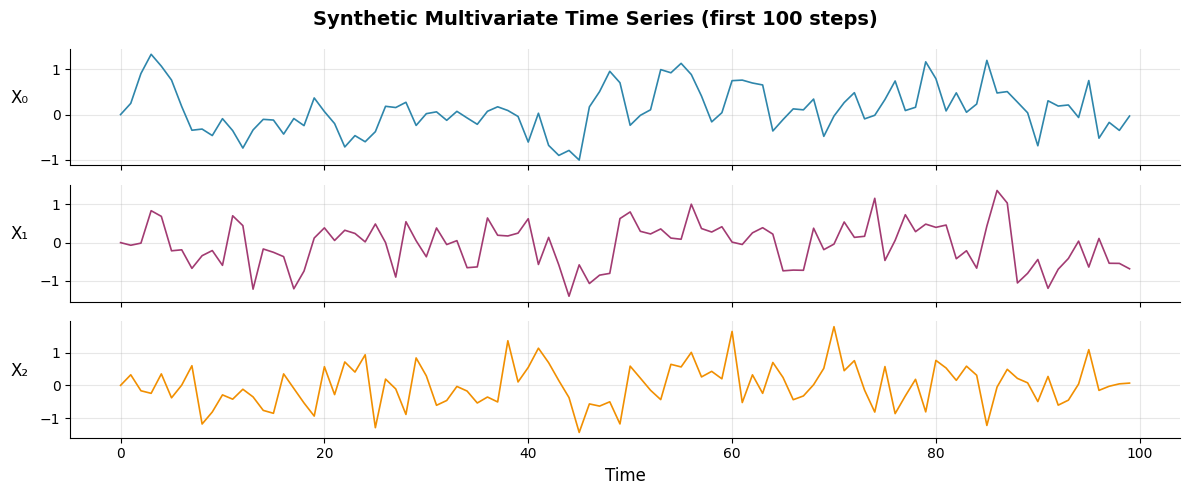

In [10]:
# Install tigramite if needed
# !pip3 install tigramite

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc

np.random.seed(42)

# ── Generate synthetic time series ──────────────────────────────────────────
T = 500          # time steps
N = 3            # number of variables
noise_scale = 0.5

X = np.zeros((T, N))

for t in range(1, T):
    X[t, 0] = 0.6 * X[t-1, 0]                         + noise_scale * np.random.randn()
    X[t, 1] = 0.5 * X[t-1, 0] + 0.3 * X[t-1, 1]      + noise_scale * np.random.randn()
    X[t, 2] =                    0.7 * X[t-1, 1]       + noise_scale * np.random.randn()

print("Time series shape:", X.shape)
print("Variables: X0, X1, X2")

# ── Plot the raw series ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)
colors = ['#2E86AB', '#A23B72', '#F18F01']
labels = ['X₀', 'X₁', 'X₂']

for i, ax in enumerate(axes):
    ax.plot(X[:100, i], color=colors[i], linewidth=1.2)
    ax.set_ylabel(labels[i], fontsize=12, rotation=0, labelpad=15)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Time', fontsize=12)
fig.suptitle('Synthetic Multivariate Time Series (first 100 steps)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

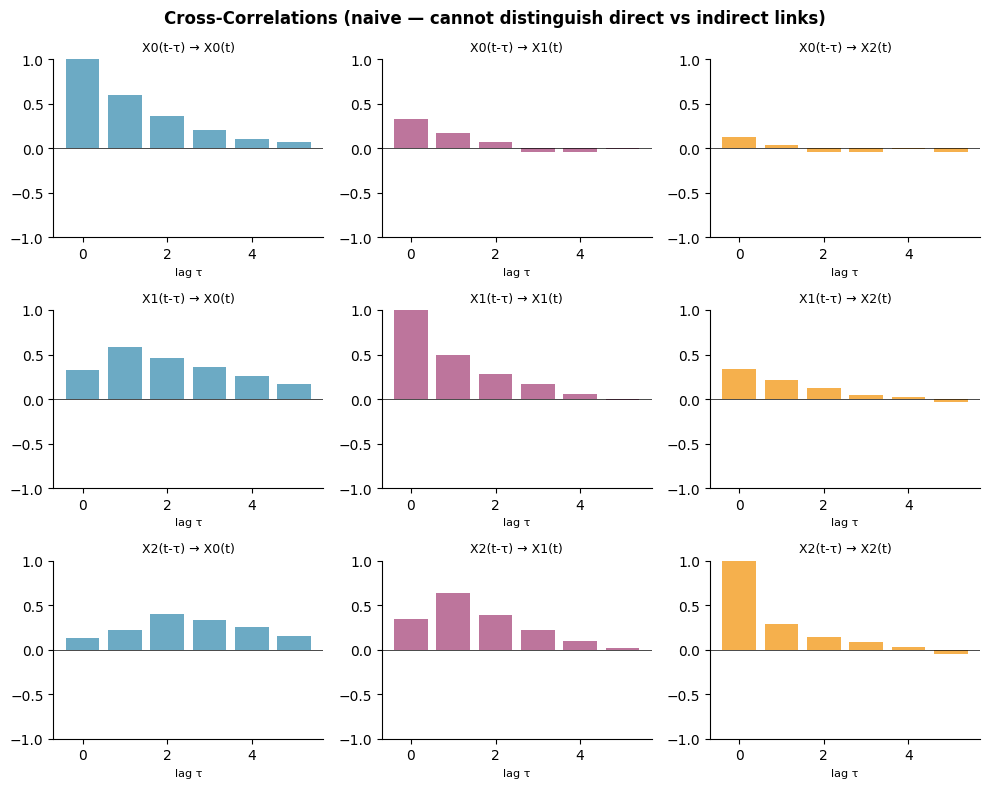


Note: X0↔X2 shows correlation even though there is NO direct causal link!
This is the indirect path: X0 → X1 → X2


In [11]:
# ── Show cross-correlations (naive approach — can mislead!) ─────────────────
from itertools import product

max_lag = 5
fig, axes = plt.subplots(N, N, figsize=(10, 8))

for i, j in product(range(N), range(N)):
    ax = axes[i][j]
    corrs = [np.corrcoef(X[lag:, i], X[:T-lag, j])[0,1] for lag in range(max_lag+1)]
    ax.bar(range(max_lag+1), corrs, color=colors[j], alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylim(-1, 1)
    ax.set_title(f'X{i}(t-τ) → X{j}(t)', fontsize=9)
    ax.set_xlabel('lag τ', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Cross-Correlations (naive — cannot distinguish direct vs indirect links)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNote: X0↔X2 shows correlation even though there is NO direct causal link!")
print("This is the indirect path: X0 → X1 → X2")

In [12]:
# ── Run PCMCI ────────────────────────────────────────────────────────────────
try:
    from tigramite import data_processing as pp
    from tigramite.pcmci import PCMCI
    from tigramite.independence_tests.parcorr import ParCorr
    import tigramite.plotting as tp
    TIGRAMITE_AVAILABLE = True
except ImportError:
    TIGRAMITE_AVAILABLE = False
    print("tigramite not installed. Run: pip install tigramite")
    print("Showing expected output below instead.")

if TIGRAMITE_AVAILABLE:
    # Wrap data in tigramite's DataFrame
    var_names = ['X0', 'X1', 'X2']
    dataframe = pp.DataFrame(X, var_names=var_names)

    # Set up PCMCI with linear partial correlation test
    parcorr = ParCorr(significance='analytic')
    pcmci = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=1)

    # Run PCMCI
    results = pcmci.run_pcmci(
        tau_max=3,          # maximum lag to consider
        pc_alpha=0.05,      # significance level for Phase 1 (PC step)
        alpha_level=0.05    # significance level for Phase 2 (MCI tests)
    )

    print("\n" + "="*60)
    print("PCMCI Results")
    print("="*60)
    pcmci.print_significant_links(
        p_matrix=results['p_matrix'],
        val_matrix=results['val_matrix'],
        alpha_level=0.05
    )


##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = par_corr
tau_min = 1
tau_max = 3
pc_alpha = [0.05]
max_conds_dim = None
max_combinations = 1



## Resulting lagged parent (super)sets:

    Variable X0 has 1 link(s):
        (X0 -1): max_pval = 0.00000, |min_val| =  0.511

    Variable X1 has 2 link(s):
        (X0 -1): max_pval = 0.00000, |min_val| =  0.526
        (X1 -1): max_pval = 0.00000, |min_val| =  0.342

    Variable X2 has 1 link(s):
        (X1 -1): max_pval = 0.00000, |min_val| =  0.535

##
## Step 2: MCI algorithm
##

Parameters:

independence test = par_corr
tau_min = 0
tau_max = 3
max_conds_py = None
max_conds_px = None

## Significant links at alpha = 0.05:

    Variable X0 has 2 link(s):
        (X0 -1): pval = 0.00000 | val =  0.511
        (X1 -3): pval = 0.00271 | val = -0.135

    Variable X1 has 2 link(s):
        (X0 -1): pval = 0.00000 | val =  0.484
        (X1 -1): pval = 0.00000 | val =  0.330

    Variable X2 

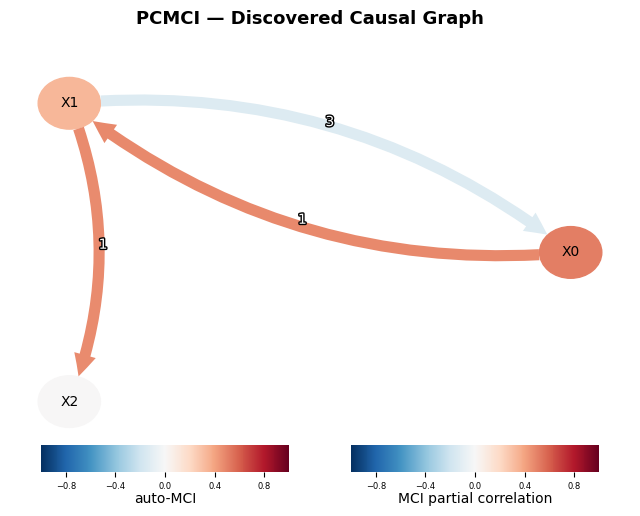

In [13]:
# ── Visualise the causal graph ───────────────────────────────────────────────
if TIGRAMITE_AVAILABLE:
    tp.plot_graph(
        val_matrix=results['val_matrix'],
        graph=results['graph'],
        var_names=var_names,
        link_colorbar_label='MCI partial correlation',
        node_colorbar_label='auto-MCI',
        figsize=(8, 5)
    )
    plt.suptitle('PCMCI — Discovered Causal Graph', fontsize=13, fontweight='bold')
    plt.show()
else:
    # ── Manual diagram of expected output ───────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 5)
    ax.axis('off')

    # Nodes
    node_pos = {'X0': (1.5, 2.5), 'X1': (5, 2.5), 'X2': (8.5, 2.5)}
    for name, (x, y) in node_pos.items():
        circle = plt.Circle((x, y), 0.6, color='#2E86AB', zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, name, ha='center', va='center', color='white',
                fontsize=13, fontweight='bold', zorder=4)

    # Edges
    arrow_props = dict(arrowstyle='->', color='#333', lw=2,
                       connectionstyle='arc3,rad=0.0')
    ax.annotate('', xy=(4.3, 2.5), xytext=(2.15, 2.5),
                arrowprops=arrow_props)
    ax.annotate('', xy=(7.8, 2.5), xytext=(5.7, 2.5),
                arrowprops=arrow_props)

    # Self-loops (autocorrelation)
    for name, (x, y) in node_pos.items():
        arc = plt.matplotlib.patches.Arc((x, y+0.55), 0.9, 0.6, angle=0,
                                          theta1=30, theta2=150, color='gray', lw=1.5)
        ax.add_patch(arc)

    ax.text(3.2, 3.0, 'lag 1\n(β=0.5)', ha='center', fontsize=9, color='#333')
    ax.text(6.7, 3.0, 'lag 1\n(β=0.7)', ha='center', fontsize=9, color='#333')
    ax.text(5, 0.8, '✗  No direct X0→X2 link detected (correctly)', 
            ha='center', fontsize=10, color='#A23B72', style='italic')

    ax.set_title('Expected PCMCI Output: Recovered Causal Graph', 
                 fontsize=13, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()

---
## 5. Interpreting the Output <a name="output"></a>

### p_matrix
Shape `(N, N, τ_max+1)` — p-values for every candidate link `(i→j, lag τ)`. A low p-value (< α) means evidence for a causal link.

### val_matrix
Shape `(N, N, τ_max+1)` — MCI test statistic values (e.g. partial correlation). Positive = positive influence, negative = inhibitory.

### graph
String array marking which links are significant (`'-->'` = causal, `''` = none).

### Reading a result entry

```
X0 --> X1  at lag 1  |  val = 0.47  |  p = 0.0001
```
Means: *X0 at time t−1 has a statistically significant causal effect on X1 at time t, with partial correlation 0.47.*

### Time series graph interpretation

| Symbol | Meaning |
|--------|--------|
| `-->` | Causal link at that lag |
| `o->` | Uncertain tail (contemporaneous) |
| `<->` | Latent common cause |
| `o-o` | No orientation determined |

---
## 6. Strengths & Limitations <a name="limits"></a>

### ✅ Strengths

| Strength | Detail |
|----------|--------|
| **Controls autocorrelation** | MCI test explicitly conditions on source parents |
| **Removes indirect links** | Conditions on target parents, eliminating spurious A→B→C paths |
| **Scales to high dimensions** | PC step prunes candidates before MCI tests |
| **Flexible CI tests** | Linear, nonlinear, and distribution-free options |
| **Multiple testing correction** | Built-in FDR/Bonferroni support |
| **Open-source** | `tigramite` library, actively maintained |

### ⚠️ Limitations

| Limitation | Detail |
|------------|--------|
| **Assumes causal sufficiency** | Cannot handle hidden/latent common causes (PCMCI+ can work around this) |
| **Stationarity required** | Data should be weakly stationary |
| **Max lag must be specified** | Wrong `τ_max` may miss long-range dependencies |
| **Large N expensive** | MCI test count grows as O(N² · τ_max) |
| **Not for contemporaneous effects** | Designed for lagged causality |

### Extensions

- **PCMCI+** — handles contemporaneous links and latent confounders
- **LPCMCI** — for latent causal systems
- **RPCMCI** — regime-dependent causal discovery

In [5]:
# ── Summary: key parameters and their role ───────────────────────────────────
print("PCMCI Key Parameters")
print("=" * 50)
params = {
    "tau_min": "Minimum lag to test (default 1)",
    "tau_max": "Maximum lag to test (domain knowledge needed)",
    "pc_alpha": "Significance level for PC step (Phase 1 pruning)",
    "alpha_level": "Significance level for MCI tests (Phase 2)",
    "cond_ind_test": "CI test: ParCorr, GPDC, CMIknn, etc.",
    "fdr_method": "Multiple testing correction: 'fdr_bh', 'bonferroni', None",
}
for param, desc in params.items():
    print(f"  {param:<18} : {desc}")

print()
print("Rule of thumb: tau_max = longest plausible delay in your domain.")
print("For financial data at daily frequency: tau_max = 5–20 (1 to 4 weeks)")

PCMCI Key Parameters
  tau_min            : Minimum lag to test (default 1)
  tau_max            : Maximum lag to test (domain knowledge needed)
  pc_alpha           : Significance level for PC step (Phase 1 pruning)
  alpha_level        : Significance level for MCI tests (Phase 2)
  cond_ind_test      : CI test: ParCorr, GPDC, CMIknn, etc.
  fdr_method         : Multiple testing correction: 'fdr_bh', 'bonferroni', None

Rule of thumb: tau_max = longest plausible delay in your domain.
For financial data at daily frequency: tau_max = 5–20 (1 to 4 weeks)


---
## 7. References <a name="refs"></a>

- **Runge, J. et al. (2019).** Detecting and quantifying causal associations in large nonlinear time series datasets. *Science Advances*, 5(11). https://doi.org/10.1126/sciadv.aau4996

- **Runge, J. (2020).** Discovering contemporaneous and lagged causal relations in autocorrelated nonlinear time series datasets. *UAI 2020*.

- **tigramite library:** https://github.com/jakobrunge/tigramite

- **Spirtes, P., Glymour, C., & Scheines, R. (2000).** *Causation, Prediction, and Search*. MIT Press. (Foundational PC algorithm)

---
